# Imports 

In [5]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import plotly.express as px

# Loading, Overview and Quality check

In [6]:
df = pd.read_csv('../data/cleaned/lagos_real_estate_market_data_cleaned.csv')
df.head()

,type,kind,price,title,location,beds,baths,agent,contact,listing_url,district
0,For Rent,Apartment,2.000000e+07,4 Units of 3 Bedroom Apartments in Lekki phase 1,Lekki Phase 1,3.0,3.0,Chinenye,+234 816 911 2079,https://cwlagos.com/property/4-units-of-3-bedr...,Lekki
1,For Sale,Detached Duplex,1.500000e+09,Luxury 5 Bedroom Fully Detached House in Lekki...,Lekki Phase 1,5.0,5.0,Chinenye,+234 816 911 2079,https://cwlagos.com/property/luxury-5-bedroom-...,Lekki
2,For Rent,Apartment,4.500000e+07,Furnished 3 Bedroom Apartment in Ikoyi,Banana Island,3.0,3.0,Adaeze,+234 816 631 5298,https://cwlagos.com/property/furnished-3-bedro...,Ikoyi
3,For Rent,Apartment,8.940853e+07,Luxury 3-Bedroom Apartment in Ikoyi,Banana Island,3.0,3.0,Adaeze,+234 816 631 5298,https://cwlagos.com/property/luxury-3-bedroom-...,Ikoyi
4,For Rent,Commercial,3.000000e+07,4 Bedroom Apartment for Commercial Use in VI,Victoria Island,0.0,0.0,Nadi,+2349062511345,https://cwlagos.com/property/4-bedroom-apartme...,Victoria Island


In [42]:
# i want to rename the column, type,  to status so it's more intuitve
df.rename(columns={'type': 'status'}, inplace=True)

In [43]:
# all the columns we have
df.columns.to_frame().T

,status,kind,price,title,location,beds,baths,agent,contact,listing_url,district
0,status,kind,price,title,location,beds,baths,agent,contact,listing_url,district


In [44]:
#We see that we have 653 listings in the data
df.shape

(653, 11)

In [45]:
#what datatypes do we have?
df.dtypes.to_frame()

,0
status,str
kind,str
price,float64
title,str
location,str
beds,float64
baths,float64
agent,str
contact,str
listing_url,str


In [46]:
#Are there any missing values?
df.isnull().sum().to_frame()

,0
status,0
kind,0
price,0
title,0
location,0
beds,0
baths,0
agent,0
contact,0
listing_url,0


In [47]:
#are there any duplicates? We know the unique id is the listing_url
df.duplicated(subset=['listing_url']).sum()

np.int64(1)

In [59]:
#What are the unique property status
print(f"There are {df['status'].nunique()} unique property status")

There are 3 unique property status


In [58]:
#How many unique listing categories are there?
print(f"There are {df['kind'].nunique()} unique listing categories")

There are 11 unique listing categories


In [56]:
#how many locations do we have?
print(f"There are {df['location'].nunique()} unique locations")

There are 21 unique locations


In [57]:
#how many unique districs do we have?
print(f"There are {df['district'].nunique()} unique districts")

There are 4 unique districts


# Understanding the Price Landscape

In [28]:
# preview to understand the data types and structure:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
type,653,3,For Rent,321,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kind,653,11,Apartment,288,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,653.0,NaN,NaN,NaN,437917935.797856,1110910028.688645,150000.0,25000000.0,120000000.0,450000000.0,15000000000.0
title,653,505,2 Bedroom Apartment in Lekki,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,653,21,Lekki Phase 1,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
beds,653.0,NaN,NaN,NaN,3.093415,2.461763,0.0,2.0,3.0,4.0,49.0
baths,653.0,NaN,NaN,NaN,3.093415,2.461763,0.0,2.0,3.0,4.0,49.0
agent,653,17,Jennifer,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,653,17,+234 704 808 9361,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listing_url,653,652,https://cwlagos.com/property/4-bedroom-flat-an...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# from the features we have we can , we can start to think throught he insighth we can find from this cleaned data
"""
first I'll explore the market overview and pricing analysis to try to understand things like
1. What does the overall price distribution of Lagos housing listings look like?


2. What is the typical (median) price range for properties in Lagos?


3. How are listings distributed across low-, mid-, and high-price segments?


4. How does price vary with number of bedrooms?


"""

"\nfirst I'll explore the market overview and pricing analysis to try to understand things like\n1. What does the overall price distribution of Lagos housing listings look like?\n\n\n2. What is the typical (median) price range for properties in Lagos?\n\n\n3. How are listings distributed across low-, mid-, and high-price segments?\n\n\n4. How does price vary with number of bedrooms?\n\n\n"

# Market Overview and Pricing

In [9]:
df['price'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
price,653.0,4.379179e+08,1.110910e+09,150000.0,25000000.0,120000000.0,450000000.0,1.500000e+10


In [10]:
df.dtypes.to_frame()

,0
type,str
kind,str
price,float64
title,str
location,str
beds,float64
baths,float64
agent,str
contact,str
listing_url,str


In [11]:
df['price'] = df['price'].astype(float)

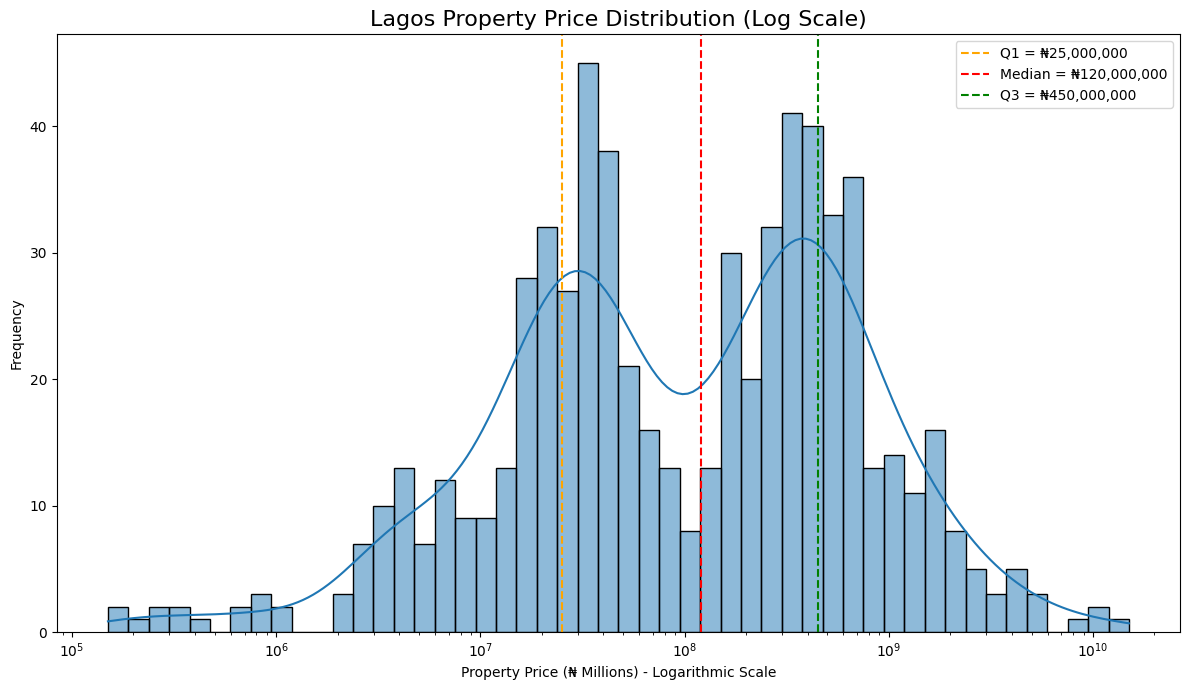

In [12]:
median_price = df['price'].median()
q1_price = df['price'].quantile(0.25)
q3_price = df['price'].quantile(0.75)

plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='price', bins=50, kde=True, log_scale=True)
plt.axvline(q1_price, color='orange', linestyle='--', label=f'Q1 = ₦{q1_price:,.0f}')
plt.axvline(median_price, color='red', linestyle='--', label=f'Median = ₦{median_price:,.0f}')
plt.axvline(q3_price, color='green', linestyle='--', label=f'Q3 = ₦{q3_price:,.0f}')
plt.title('Lagos Property Price Distribution (Log Scale)', fontsize=16)
plt.xlabel('Property Price (₦ Millions) - Logarithmic Scale')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
""" 
We see that the house prices in lagos are slightly skewed to the right, there are very little houses at the 
lower end of the price spectrum 
The price distrbution almost follows a guassiona dist, but for the dip in the median price, which is around 120m. 


"""

' \nWe see that the house prices in lagos are slightly skewed to the right, there are very little houses at the \nlower end of the price spectrum \nThe price distrbution almost follows a guassiona dist, but for the dip in the median price, which is around 120m. \n\n\n'

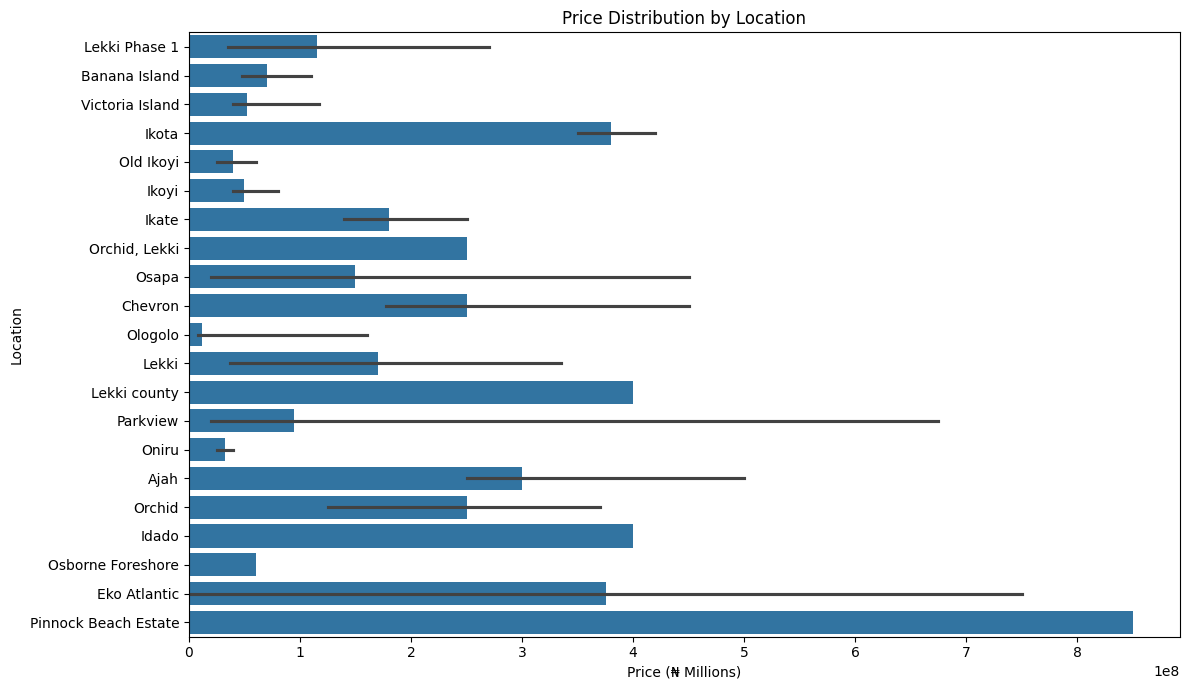

In [14]:
#plotting a graph of the price distribution in each location

plt.figure(figsize=(12,7))
sns.barplot(data=df, x="price", y="location", estimator= np.median)
plt.title("Price Distribution by Location")
plt.xlabel("Price (₦ Millions)")
plt.ylabel("Location")
plt.tight_layout()
plt.show()


<Figure size 1200x700 with 0 Axes>

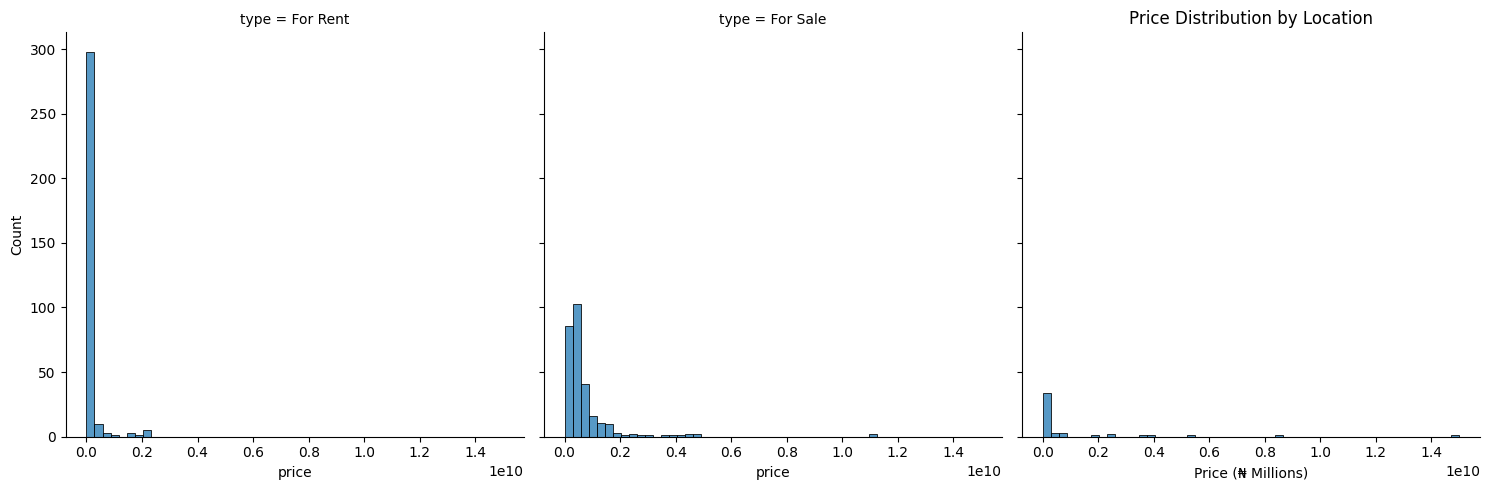

In [15]:
#plotting a graph of the price distribution for each type of property

plt.figure(figsize=(12,7))
sns.displot(data=df, x="price", col="type")
plt.title("Price Distribution by Location")
plt.xlabel("Price (₦ Millions)")
plt.ylabel("Location")
plt.tight_layout()
plt.show()


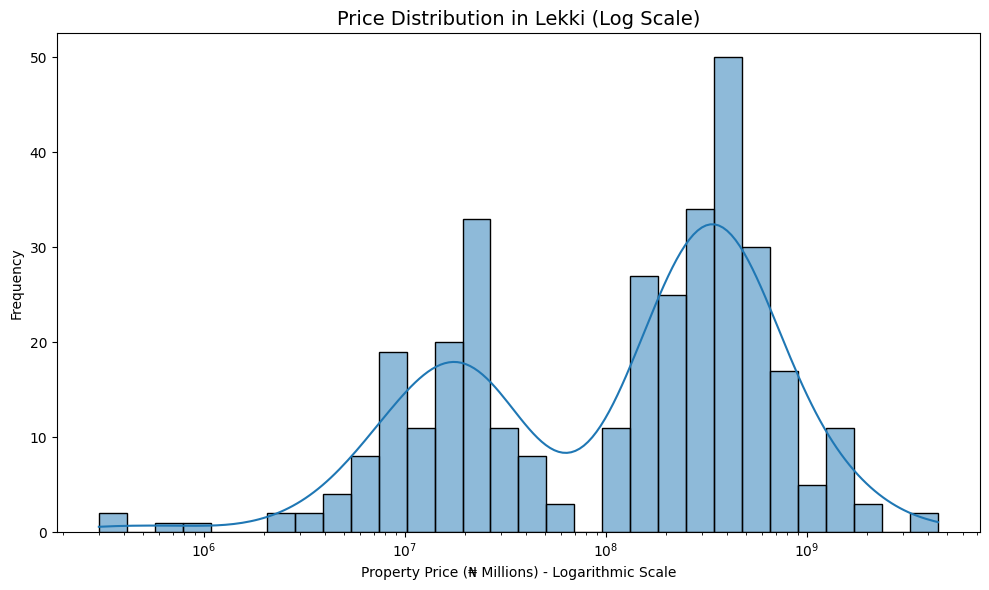

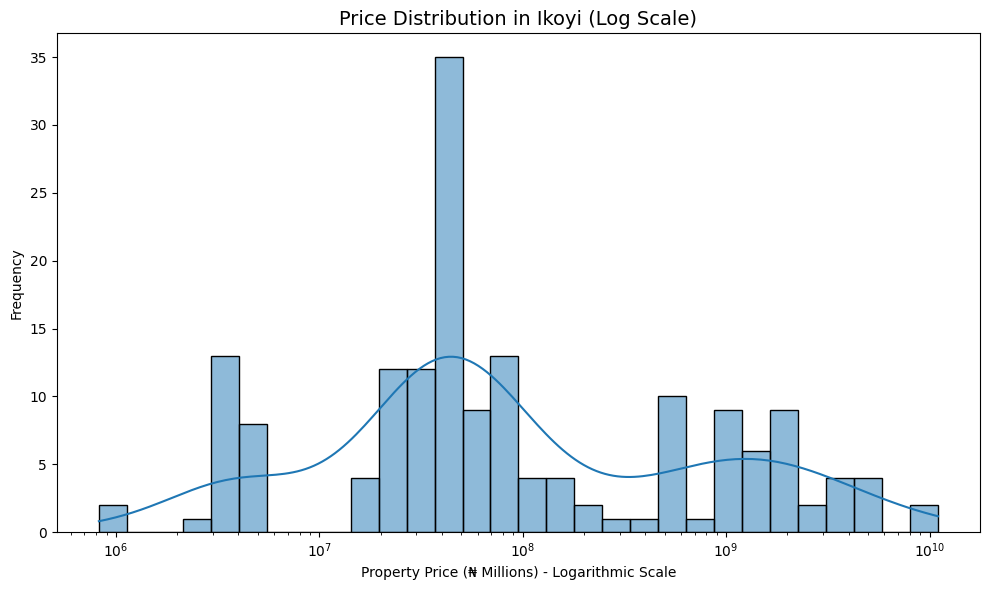

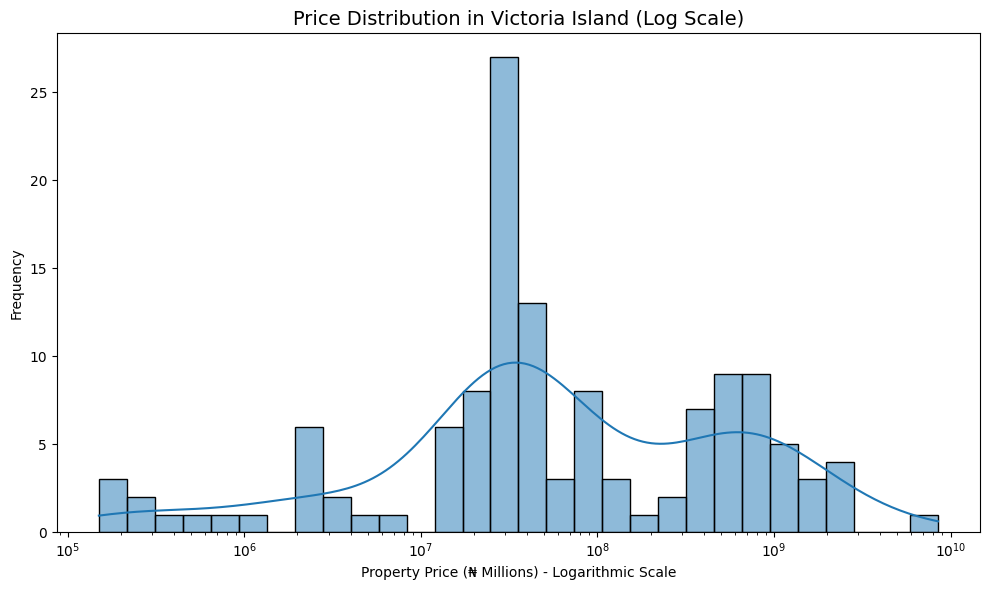

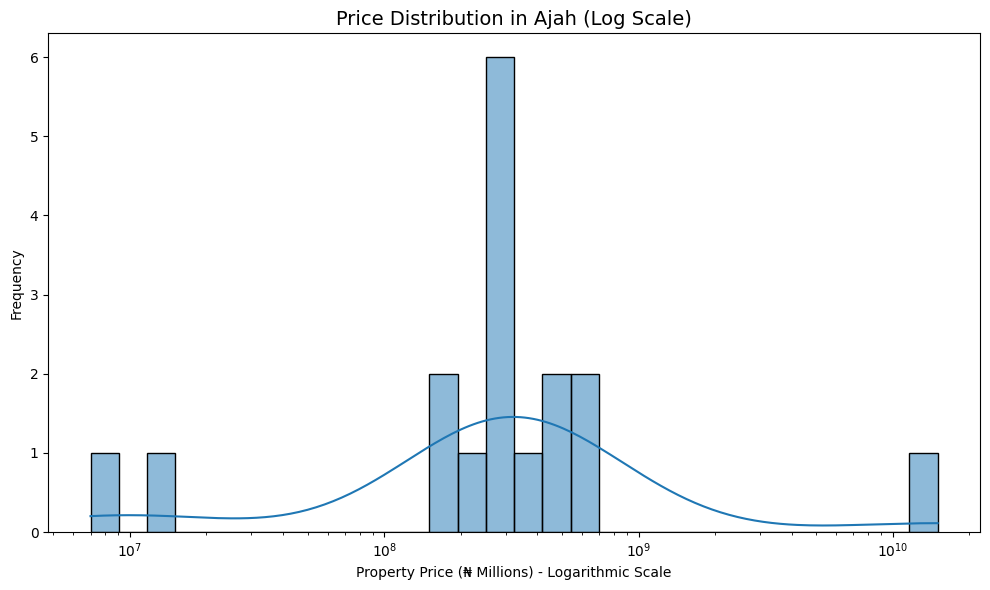

In [16]:
# relationship between price and district
for district in df['district'].unique():
    district_data = df[df['district'] == district]
    plt.figure(figsize=(10, 6))
    sns.histplot(district_data['price'], bins=30, kde=True, log_scale=True)
    plt.title(f'Price Distribution in {district} (Log Scale)', fontsize=14)
    plt.xlabel('Property Price (₦ Millions) - Logarithmic Scale')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [17]:
type
kind	
price	
title	
location	
beds	
baths	
agent	
contact	
listing_url	
district


NameError: name 'kind' is not defined